In [4]:
!pip install gdown

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   -------------------------- ------------- 2/3 [gdown]
   ---------------------------------------- 3/3 [gdown]



In [2]:
# Download and then load the file:
import gdown
import pandas as pd

file_id = '1fmeZ0I_dAsE545fBfO0U8tZVkK4VqI4O'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'cleaned_real_estate.csv'

# This bypasses the "too large to scan" warning automatically
gdown.download(url, output, quiet=False)

# Now load the local file
df = pd.read_csv(output)
print("File loaded successfully!")
print(df.head())

Downloading...
From (original): https://drive.google.com/uc?id=1fmeZ0I_dAsE545fBfO0U8tZVkK4VqI4O
From (redirected): https://drive.google.com/uc?id=1fmeZ0I_dAsE545fBfO0U8tZVkK4VqI4O&confirm=t&uuid=7715a035-5b21-4e17-be2a-1e690f10fd3f
To: C:\Users\HP\DataScience\DSBDA Mini Project\cleaned_real_estate.csv
100%|████████████████████████████████████████████████████████████████████████████████| 128M/128M [03:27<00:00, 616kB/s]


File loaded successfully!
      Price  Area_SqFt  Bedrooms  Location  Bathrooms  Source  Price_Per_SqFt
0  0.117684   0.227638  0.333333  0.003587   0.333333     0.0        0.256978
1  0.089664   0.401663  0.666667  0.003587   0.333333     0.0        0.117963
2  0.075094   0.178326  0.000000  0.436827   0.000000     0.0        0.201682
3  0.162516   0.479931  0.666667  0.712919   0.333333     0.0        0.181380
4  0.200624   0.686353  0.666667  0.790241   0.666667     0.0        0.159936


In [3]:
# import required libraries:
from sklearn.linear_model import LassoCV 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


In [4]:
# Separating dependent and independent variables
X = df.drop(columns=['Price']) # independent variables
y = df['Price'] # target variable

In [5]:
# Splitting data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [6]:
# Training model:
# alpha = [0.001,0.1,1,2,3,5,10,20,30,40,50,100] #Alpha Values

lasso_cv = LassoCV(cv=5,random_state=42)
lasso_cv.fit(X_train,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [7]:
print("Best Alpha Value:",lasso_cv.alpha_)

Best Alpha Value: 2.881244466415364e-05


In [8]:
# Getting test results:
y_pred = lasso_cv.predict(X_test)

In [9]:
mse = mean_squared_error(y_test,y_pred)
print("MSE:", mse)

MSE: 0.0028479371161085057


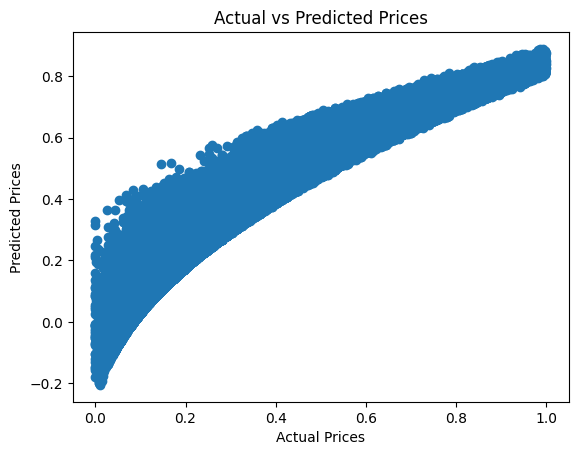

In [10]:
# Plotting the Test Results and Expected Values:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

In [11]:
# Calculating Model Evaluation Metrics:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.03614677318137473
RMSE: 0.05336606708488556
R² Score: 0.9306674813652053


In [12]:
import joblib
joblib.dump(lasso_cv, 'trained_real_estate_model.pkl')

['trained_real_estate_model.pkl']